# Simulation of the Fermi-Hubbard model on the square lattice 

### Hamiltonian evolution

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from src.resource_estimates.gate_costs.hamming_weight_phasing import HWPGate
from src.resource_estimates.gate_costs.free_fermionic import FreeFermionicC4Tile
from src.resource_estimates.gate_costs.interactions import ShiftedOccupationPair
from src.resource_estimates.gate_costs.hubbard_commutators import (
    SpinSymmetricMixedControlledKappa, 
    SpinSymmetricMixedControlledHappa,
    MixedControlledHappa
)
from src.resource_estimates.gate_costs.fermionic_swap import fswap_network_count, Fswap

from src.resource_estimates.hamiltonian_simulation import hamiltonian_simulation_cost
from src.resource_estimates.quantum_phase_estimation import adaptive_phase_estimation_resources

from src.hubbard_models.square_hubbard_model import (
    compute_number_of_trotter_steps,
    compute_evolution_time_and_number_of_simulation_circuits_for_qpe,
    plaquette_decomposition_permutations,
    augmented_permutations,
)

In [2]:
tau = 0.5
U = 4
x = 0.01

def get_trotter_count_func(type: str, s: int):
    def f(t,e):
        return compute_number_of_trotter_steps(
            t,e,U,tau,s, type
        )
    return f

def gates_2nd_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 3,
        HWPGate({ShiftedOccupationPair():L**2}, m): 1,
        Fswap(): 4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, m): 1}

def gates_4th_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 15,
        HWPGate({ShiftedOccupationPair():L**2}, m): 5,
        Fswap(): 5*4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, m): 1}

def gates_augmented(L: int) -> tuple[dict, ...]:
    m = L**2//2
    aug_counts = {x: fswap_network_count(y) for x,y in augmented_permutations(L).items()}
    fswap_count = 2*(4*fswap_network_count(plaquette_decomposition_permutations(L))
                +2*aug_counts["red_to_augred"] + 2*aug_counts["augred_to_augblue"]
                +2*aug_counts["red_reflection"]
        )
    return {
       HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6,
         HWPGate({ShiftedOccupationPair():L**2}, m): 2,
        HWPGate({SpinSymmetricMixedControlledHappa(): L**2 // 2}, m): 4,
        Fswap(): fswap_count
    }, {HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 5, HWPGate({SpinSymmetricMixedControlledKappa(): L**2//2}, m): 8}

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

def dict_to_cx_count(dct: dict) -> int:
    cxc = 0
    if "cx" in dct.keys():
        cxc += dct["cx"] 
        
    if "toffoli" in dct.keys():
        cxc += 4*dct["toffoli"]

    if "fswap" in dct.keys():
        cxc += 2*dct["fswap"]
    return cxc

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


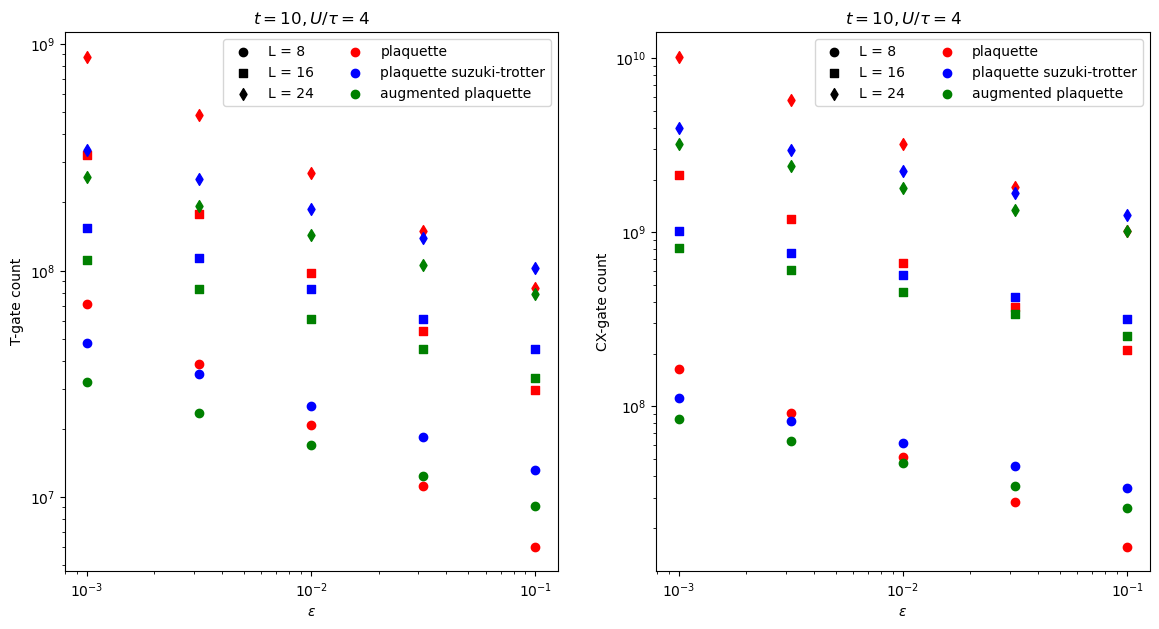

In [3]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [8, 16, 24]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

fig, (ax_t, ax_cx) = plt.subplots(1,2, figsize = (14, 7))

for ax, g in zip([ax_t, ax_cx], ["T", "CX"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2)
    ax.set_xlabel(rf"$\varepsilon$")
    ax.set_ylabel(f"{g}-gate count")
    ax.legend(ncol = 2)
    ax.set_title(rf"$t = {t}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        dcts = [hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            trotter_steps_from_time_and_error=get_trotter_count_func(comp_strat, L),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ys_cx = [dict_to_cx_count(d) for d in dcts]
        ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
        ax_cx.scatter(eps_list, ys_cx, marker = marker_style, c = color)

plaquette
t: [605564, 1322504, 2932608, 6408300, 13997976, 30578580, 67699932, 147811944, 322670884, 713389308]
cx: [1569168, 3396876, 7358664, 15943764, 34536000, 74824860, 162114456, 351215796, 760882224, 1648383564]
t: [2969932, 6450972, 14003772, 30656076, 66568332, 144536604, 313829932, 686620828, 1490585004, 3235728444]
cx: [21014316, 45333756, 97736476, 210806748, 454679516, 980635500, 2115145596, 4562148316, 9840116460, 21224177532]
t: [8353122, 18077844, 39132534, 84705048, 184264332, 398891182, 863497728, 1869214810, 4065301982, 8799562344]
cx: [101841630, 219436752, 472903122, 1019092356, 2196468798, 4734025240, 10203247098, 21991088812, 47397366038, 102155396448]
plaquette suzuki-trotter
t: [1325736, 2542628, 4876160, 9519384, 18280756, 35130288, 67507260, 129670472, 249079444, 478384736]
cx: [3405180, 6473352, 12306564, 23486016, 44479296, 84790668, 161653080, 308109732, 587347824, 1113480624]
t: [4520540, 8603516, 16568028, 31629884, 60395100, 115405516, 220462492, 421138

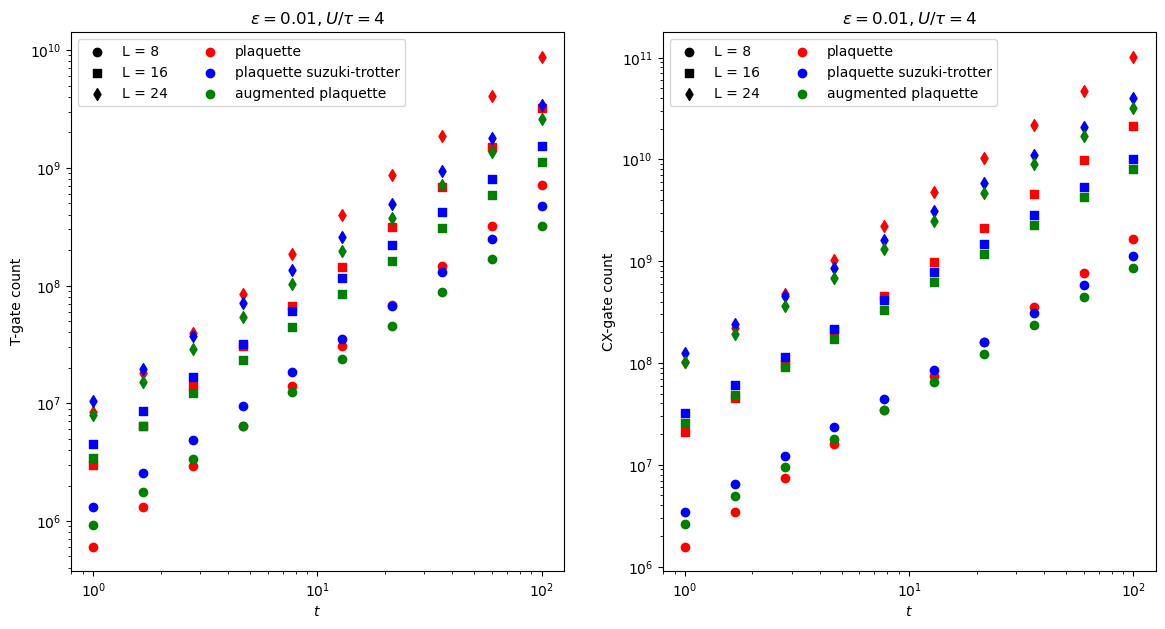

In [4]:
logts = np.linspace(0, 2, 10)
ts = np.pow(10, logts)
eps = 0.01
Ls = [8, 16, 24]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

fig, (ax_t, ax_cx) = plt.subplots(1,2, figsize = (14, 7))

for ax, g in zip([ax_t, ax_cx], ["T", "CX"]):
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2)
    ax.set_xlabel(rf"$t$")
    ax.set_ylabel(f"{g}-gate count")
    ax.legend(ncol = 2)
    ax.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    print(comp_strat)
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        dcts = [hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            trotter_steps_from_time_and_error=get_trotter_count_func(comp_strat, L),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for t in ts
               ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ys_cx = [dict_to_cx_count(d) for d in dcts]
        print("t:", ys_t)
        print("cx:", ys_cx)
        ax_t.scatter(ts, ys_t, marker = marker_style, c = color)
        ax_cx.scatter(ts, ys_cx, marker = marker_style, c = color)

# Quantum Phase Estimation

In [5]:
tau = 0.5
U = 4
x = 0.01

import math

def qubitization_t_count(eps: float, N: int) -> int:
    return math.ceil((40*np.sqrt(2) * np.pi* tau + 5*np.sqrt(2) * np.pi*U) * N**2 / eps)

def get_evolution_time_and_count_func(type: str, s: int):
    def f(e):
        return compute_evolution_time_and_number_of_simulation_circuits_for_qpe(
            e,U,tau,s, type, unitary_decomp=False
        )
    return f


def get_trotter_count_func(type: str, s: int):
    def f(t,e):
        return compute_number_of_trotter_steps(
            t,e,U,tau,s, type, 
        )
    return f

def gates_2nd_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 3,
        HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1,
        Fswap(): 4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1}

def gates_4th_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 15,
        HWPGate({ShiftedOccupationPair():L**2}, 2*m): 5,
        Fswap(): 5*4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1}

def gates_augmented(L: int) -> tuple[dict, ...]:
    m = L**2//2
    aug_counts = {x: fswap_network_count(y) for x,y in augmented_permutations(L).items()}
    fswap_count = 2*(4*fswap_network_count(plaquette_decomposition_permutations(L))
                +2*aug_counts["red_to_augred"] + 2*aug_counts["augred_to_augblue"]
                +2*aug_counts["red_reflection"]
        )
    return {
       HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6,
         HWPGate({ShiftedOccupationPair():L**2}, 2*m): 2,
        HWPGate({SpinSymmetricMixedControlledHappa(): L**2 // 2}, m): 4,
        Fswap(): fswap_count
    }, {HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6, HWPGate({SpinSymmetricMixedControlledKappa(): L**2//2}, m): 8}

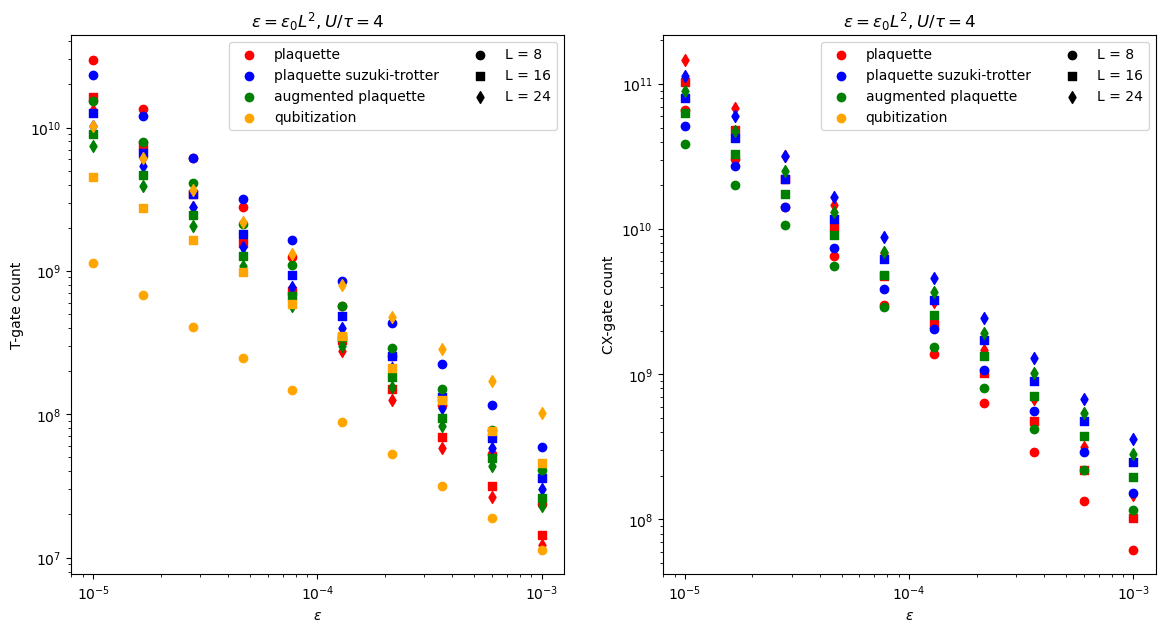

In [6]:
logeps_list = np.linspace(-5, -3, 10)
eps_list = np.pow(10, logeps_list)
Ls = [8, 16, 24]

colors = ['r', 'b', 'g', "orange"]
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette", "qubitization"]

fig, (ax_t, ax_cx) = plt.subplots(1,2, figsize = (14, 7))

for ax, g in zip([ax_t, ax_cx], ["T", "CX"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2)
    ax.set_xlabel(rf"$\varepsilon$")
    ax.set_ylabel(f"{g}-gate count")
    ax.legend(ncol = 2)
    ax.set_title(rf"$\varepsilon = \varepsilon_0 L^2, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented, _], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        if comp_strat == "qubitization":
            ys_t = [qubitization_t_count(e * L**2, L**2) for e in eps_list]
            ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
        else:
            t_gates, u_gates = gate_gen(L)
            dcts = [adaptive_phase_estimation_resources(
                e * L**2, 
                t_gates, 
                unitary_gates=u_gates, 
                simulation_steps_and_time_from_error=get_evolution_time_and_count_func(comp_strat, L),
                x=x,
                synthesize_rotation_with="RUS"
            )
                for e in eps_list
                   ]
            ys_t = [dict_to_t_count(d) for d in dcts]
            ys_cx = [dict_to_cx_count(d) for d in dcts]
            ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
            ax_cx.scatter(eps_list, ys_cx, marker = marker_style, c = color)

plaquette
t: [426191568, 1028394856, 2047472184, 3522958317, 5748543658, 8620324106, 12586416306]
cx: [1034138808, 4497560992, 13379062664, 31603066483, 64345332430, 117634135630, 198937761147]
t: [1234348877, 2959275992, 5906482746, 10060571745, 16453743120, 24608794364, 35887363551]
cx: [2953880275, 12771551660, 37956975502, 89482977555, 182125358520, 332870359206, 562967664270]
t: [14931823308, 35064290386, 69047025144, 116245572006, 189032539232, 281055181584, 407667421110]
cx: [33833417520, 144203376042, 426521782048, 1003139075986, 2039847108848, 3725830520512, 6299528873710]
plaquette suzuki-trotter
t: [658645944, 1294244568, 2229236508, 3429149568, 5106599120, 7088634174, 9654434100]
cx: [1606090128, 5660243892, 14566817198, 30761584896, 57159861392, 96732421050, 153007761060]
t: [1622861580, 3131744128, 5407662450, 8234695953, 12242452500, 17016417896, 23148080384]
cx: [3857449484, 13515894196, 34716181652, 73242840627, 136046930796, 230172076380, 364036606361]
t: [12976438140

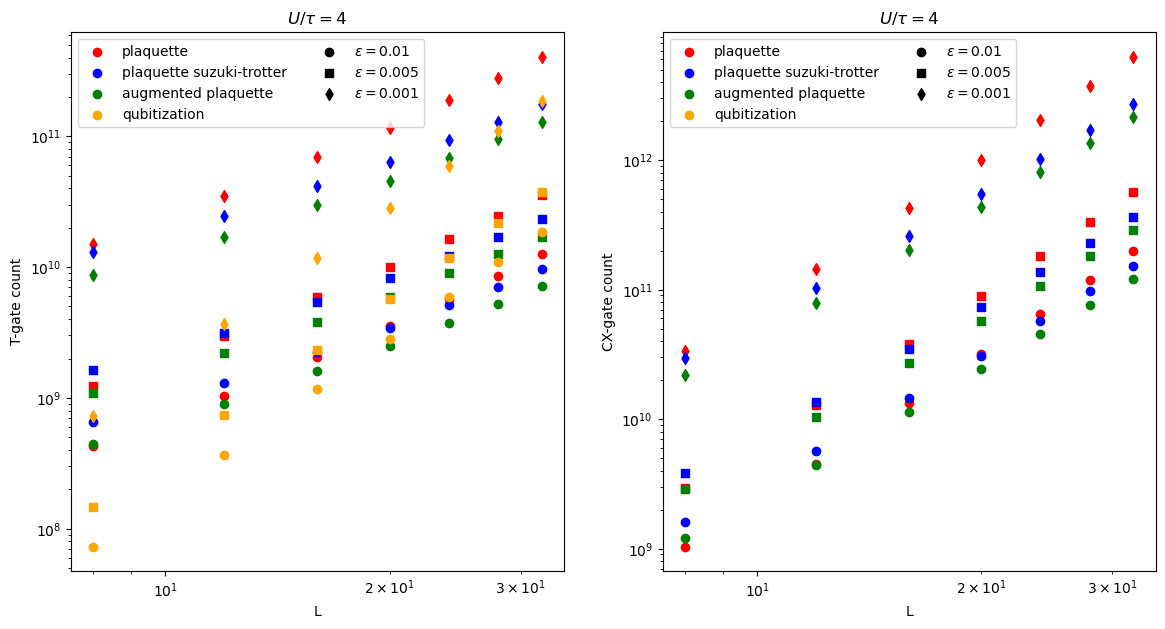

In [7]:
Ls = [8, 12, 16, 20, 24, 28, 32]
epss = [0.01, 0.005, 0.001]

colors = ['r', 'b', 'g', "orange"]
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette", "qubitization"]

fig, (ax_t, ax_cx) = plt.subplots(1,2, figsize = (14, 7))

for ax, g in zip([ax_t, ax_cx], ["T", "CX"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for e, marker in zip(epss, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = rf"$\varepsilon = {e}$")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2)
    ax.set_xlabel(rf"L")
    ax.set_ylabel(f"{g}-gate count")
    ax.legend(ncol = 2)
    ax.set_title(rf"$U / \tau = {U}$")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented, "_"], colors, comp_strats):
    print(comp_strat)
    for e, marker_style in zip(epss, marker_styles):
        if comp_strat == "qubitization":
            ys_t = [qubitization_t_count(e , L**2) for L in Ls]
            ax_t.scatter(Ls, ys_t, marker = marker_style, c = color)
        else:
            ys_t, ys_cx = [], []
            for L in Ls:
                t_gates, u_gates = gate_gen(L)
                dct = adaptive_phase_estimation_resources(
                    e, 
                    t_gates, 
                    unitary_gates=u_gates, 
                    simulation_steps_and_time_from_error=get_evolution_time_and_count_func(comp_strat, L),
                    x=x,
                    synthesize_rotation_with="RUS"
                )
                ys_t.append(dict_to_t_count(dct))
                ys_cx.append(dict_to_cx_count(dct))
            ax_t.scatter(Ls, ys_t, marker = marker_style, c = color)
            ax_cx.scatter(Ls, ys_cx, marker = marker_style, c = color)
        print("t:", ys_t)
        print("cx:", ys_cx)
        